## ChemBERTa Fine-Tuning for Molecular Classification

Step 1: Install dependencies

In [1]:
!pip install -q transformers datasets torch scikit-learn pandas

In [2]:
import torch
import pandas as pd
import sklearn
import transformers
import datasets

In [6]:
print("Torch Version", torch.__version__)
print("GPU available", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Torch Version 2.10.0+cu128
GPU available True
GPU name: NVIDIA A100-SXM4-40GB


# step 2: Uploading the SMILES Dataset

In [7]:
from google.colab import files
uploaded = files.upload()

Saving BBBP.csv to BBBP.csv


In [40]:
df= pd.read_csv("/content/BBBP.csv")


In [41]:
df.head()

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   num     2050 non-null   int64 
 1   name    2050 non-null   object
 2   p_np    2050 non-null   int64 
 3   smiles  2050 non-null   object
dtypes: int64(2), object(2)
memory usage: 64.2+ KB


In [28]:
# check the class balance(label distribution)
df['p_np'].value_counts()

,count
p_np,
1,1567
0,483


In [32]:
df['label']=df['p_np'].rename("labels", inplace=True)

In [33]:
df.head()

,num,name,p_np,smiles,label
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


In [38]:
df['smiles_length']= df['smiles'].apply(len)
df['smiles_length'].describe()

,smiles_length
count,2050.000000
mean,51.474146
std,30.620659
min,3.000000
25%,33.000000
50%,45.000000
75%,61.000000
max,400.000000


Step 3: convert the data in Huggingface Dataset + Train/Test Split

In [44]:
df=df[['smiles','p_np']]
df=df.rename(columns={'p_np': "label"})
df.head()

,smiles,label
0,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


In [56]:
from datasets import Dataset
dataset=Dataset.from_pandas(df)
dataset

Dataset({
    features: ['smiles', 'label'],
    num_rows: 2050
})

In [57]:
dataset=dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['smiles', 'label'],
        num_rows: 1640
    })
    test: Dataset({
        features: ['smiles', 'label'],
        num_rows: 410
    })
})

In [60]:
dataset['train'][0]

{'smiles': '[N]14C3=C(C2=C1C=CC(=C2)C)CCCC3NCC4.[H+].[Cl-]', 'label': 1}

# step 4: Load ChemBERTa Tokenizer and Tokenize SMILES

## SMILES → tokens → token IDs

In [65]:
from transformers import AutoTokenizer
tokenizer= AutoTokenizer.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k")

In [68]:
def tokenizer_function(example):
  return tokenizer(
      example['smiles'],
      padding="max_length",
      truncate=True,
      max_length=128
  )

In [69]:
# Apply tokenization to the dataset
tokenized_data = dataset.map(tokenizer_function, batched=True)

Map:   0%|          | 0/1640 [00:00<?, ? examples/s]

Map:   0%|          | 0/410 [00:00<?, ? examples/s]

In [71]:
tokenized_data['train'][0]

{'smiles': '[N]14C3=C(C2=C1C=CC(=C2)C)CCCC3NCC4.[H+].[Cl-]',
 'label': 1,
 'input_ids': [0,
  63,
  50,
  65,
  747,
  39,
  23,
  33,
  39,
  12,
  39,
  22,
  33,
  39,
  21,
  39,
  33,
  262,
  263,
  39,
  22,
  13,
  39,
  13,
  285,
  23,
  321,
  24,
  18,
  63,
  44,
  274,
  18,
  63,
  278,
  287,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
 

In [72]:
# Remove the raw smiels column we do not need it anymore
tokenized_data= tokenized_data.remove_columns(['smiles'])

In [73]:
# set Pytorch format (tensors)
tokenized_data.set_format('torch')

In [75]:
tokenized_data['test'][0]

{'label': tensor(0),
 'input_ids': tensor([  0,  63,  50,  69, 274,  18, 262,  21,  12,  39,  13,  55,  63,  39,
         266,  44,  65,  22,  63,  39,  36,  44, 265, 268, 263,  51, 272,  39,
          36,  44, 265, 268, 263,  51,  13,  39,  23,  33, 262,  33,  39,  12,
         268,  23,  33,  51,  13,  71,  24, 264,  12, 261,  24, 272,  55,  65,
         263,  51, 288,  51,  13,  50,  12, 289,  13, 289,  13,  71,  25, 264,
          12,  51,  13, 261,  25,  13,  39, 263,  51,  13,  50,  22,  63,  39,
          36,  44,  65,  21,  39, 284,  51, 400,  51,   2,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

#Pipeline
CSV dataset

      ↓
Pandas dataframe

      ↓
HuggingFace Dataset

      ↓
Train/Test split

      ↓
Tokenization

      ↓
PyTorch tensors ID

      ↓
ChemBERTa Transformer

      ↓
Classification head

      ↓
Prediction


# step 5: Load the ChemBERTa model for binary classification

## Right now we only have tokens but we still need the model architecture.
## The pre-trained ChemBERTa model contains SMILES embeddings + Transformer encoder layer, on top of this we will add the classification head.

SMILES → Transformer → Classification Layer → Prediction (0 or 1)

In [77]:
# Load the pre-trained model
from transformers import AutoModelForSequenceClassification as ASC

model = ASC.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k")

pytorch_model.bin:   0%|          | 0.00/336M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: seyonec/ChemBERTa_zinc250k_v2_40k
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [81]:
# move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [82]:
# model architecture
print(model)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

Fine-tuning works like this:

Pretrained ChemBERTa

        ↓
Add classification head

        ↓
Train on your dataset

So the model already understands chemical structures, and we only teach it how to classify them.

# step 6: Configure Training Arguments

Fine-tuning heavily depends on the training hyperparameters

1. Learning rate
2. batch_size
3. epoch
4. evaluation frequency
5. model checkpointing

Bad setting can cause:
1. unstable training
2. overfitting
3. slow convergence



In [85]:
# import training arguments
from transformers import TrainingArguments
training_args= TrainingArguments(
    output_dir="./results",
    learning_rate= 2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=5,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir="./logs",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Step 7:Define Metrics and Create the Trainer

model

training arguments

dataset

evaluation metrics

In [92]:
from transformers import Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)

  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')

  acc = accuracy_score(labels, predictions)

  return {
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall
  }


| Metric    | Meaning                                  |
| --------- | ---------------------------------------- |
| Accuracy  | overall correctness                      |
| Precision | how many predicted positives are correct |
| Recall    | how many real positives are detected     |
| F1 score  | balance between precision and recall     |


In [93]:
from transformers import Trainer, DataCollatorWithPadding

# Create a data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create Trainer
trainer= Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['test'],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Trainer automatically handles
1. batch loading
2. forward pass
3. oss calculation
4. backpropagation
5. evaluation
6. logging
7. checkpoint saving

Checkpoints help with:

| Purpose             | Benefit                  |
| ------------------- | ------------------------ |
| Recover training    | prevents losing progress |
| Save best model     | avoids overfitting       |
| Experiment tracking | compare different models |
| Deployment          | keep best model          |


In [94]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.318325,0.907317,0.938907,0.921136,0.957377
2,No log,0.358769,0.895122,0.930533,0.917197,0.944262
3,0.164535,0.438720,0.892683,0.928339,0.922330,0.934426
4,0.164535,0.508109,0.890244,0.926591,0.922078,0.931148
5,0.062346,0.519044,0.890244,0.927066,0.916667,0.937705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1025, training_loss=0.111270773468948, metrics={'train_runtime': 39.2512, 'train_samples_per_second': 208.911, 'train_steps_per_second': 26.114, 'total_flos': 279996754499808.0, 'train_loss': 0.111270773468948, 'epoch': 5.0})

# step 9: Evaluate the model performance

Training alone does not tell us if the model learned anything useful.

Evaluation checks performance on unseen data (the test split).

In [160]:
baseline_results = trainer.evaluate()

# The Medium guide also covers different fine-tuning strategies, such as:

#Fine-Tuning Method :

1️⃣ Class imbalance handling (class weights)

2️⃣ Freezing BERT layers

3️⃣ Custom classification head

4️⃣ Domain adaptation (MLM pretraining)

5️⃣ Hyperparameter tuning


Step 10: Handle Class Imbalance (Class Weights)

In [99]:
df['label'].value_counts()

,count
label,
1,1567
0,483


In [101]:
# compute the class weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["label"]),
    y=df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([2.1222, 0.6541])


In [106]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):

        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [112]:
# create a new Trainer
weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator

)

In [113]:
weighted_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.708331,0.895122,0.930533,0.917197,0.944262
2,No log,0.608598,0.892683,0.928339,0.922330,0.934426
3,0.175105,0.606761,0.892683,0.927152,0.936455,0.918033
4,0.175105,0.737942,0.890244,0.926350,0.924837,0.927869
5,0.048787,0.754123,0.890244,0.925865,0.930464,0.921311


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1025, training_loss=0.10944790233926076, metrics={'train_runtime': 42.8911, 'train_samples_per_second': 191.182, 'train_steps_per_second': 23.898, 'total_flos': 279996754499808.0, 'train_loss': 0.10944790233926076, 'epoch': 5.0})

In [161]:
weighted_results = weighted_trainer.evaluate()

# Step 11: Fine-Tuning Method 2
## Freeze Transformer Layer
Why we freeze layers

A pretrained transformer like ChemBERTa already learned general chemical representations from millions of molecules.

When we fine-tune on a small dataset, updating all layers can cause:

overfitting

unstable training

loss of pretrained knowledge

SMILES

     ↓
Transformer layers (frozen)

     ↓
Classification head (trainable)

In [116]:
from transformers import AutoModelForSequenceClassification

model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "seyonec/ChemBERTa_zinc250k_v2_40k",
    num_labels=2
)

for param in model_frozen.roberta.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: seyonec/ChemBERTa_zinc250k_v2_40k
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [117]:
for name, param in model_frozen.named_parameters():
    if param.requires_grad:
        print(name)

classifier.dense.weight
classifier.dense.bias
classifier.out_proj.weight
classifier.out_proj.bias


In [118]:
model_frozen.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [120]:
frozen_trainer = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator

)

In [121]:
frozen_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.392392,0.809756,0.885630,0.801061,0.990164
2,No log,0.352522,0.831707,0.891680,0.855422,0.931148
3,0.391591,0.342114,0.831707,0.892019,0.853293,0.934426
4,0.391591,0.335474,0.834146,0.893417,0.855856,0.934426
5,0.334300,0.335105,0.836585,0.895149,0.856287,0.937705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1025, training_loss=0.36071119913240757, metrics={'train_runtime': 21.1577, 'train_samples_per_second': 387.566, 'train_steps_per_second': 48.446, 'total_flos': 279996754499808.0, 'train_loss': 0.36071119913240757, 'epoch': 5.0})

In [162]:
frozen_results = frozen_trainer.evaluate()

# Step 12 — Fine-Tuning Method 4: Custom Classification Head
Why this method helps

By default, BERT-style models use a very simple classifier:

Transformer → Linear layer → Output

But sometimes a deeper classifier performs better.

We can modify it to:

Transformer → Dense → ReLU → Dropout → Linear → Output

This allows the model to learn more complex patterns in molecular features.

In [125]:
# Reload the model
model= AutoModelForSequenceClassification.from_pretrained(
    "seyonec/ChemBERTa_zinc250k_v2_40k",
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: seyonec/ChemBERTa_zinc250k_v2_40k
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [135]:
import torch
import torch.nn as nn

class CustomChemBERTa(nn.Module):

    def __init__(self):
        super(CustomChemBERTa, self).__init__()

        self.bert = model

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids=None, attention_mask=None, labels=None):

        # Access the base RobertaModel to get last_hidden_state
        roberta_outputs = self.bert.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled_output = roberta_outputs.last_hidden_state[:,0] # Get the [CLS] token representation

        logits = self.classifier(pooled_output)

        loss = None

        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}

In [136]:
# initialize the model
custom_model = CustomChemBERTa()

custom_model.to(device)

CustomChemBERTa(
  (bert): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(52000, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-5): 6 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dense): L

In [137]:
# create trainer
custom_trainer = Trainer(
    model=custom_model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

In [138]:
custom_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.275310,0.912195,0.943574,0.903904,0.986885
2,No log,0.258370,0.885366,0.923577,0.916129,0.931148
3,0.252108,0.296741,0.890244,0.925125,0.939189,0.911475
4,0.252108,0.328989,0.887805,0.924092,0.930233,0.918033
5,0.124065,0.340802,0.890244,0.925125,0.939189,0.911475


TrainOutput(global_step=1025, training_loss=0.18502343166165236, metrics={'train_runtime': 41.3931, 'train_samples_per_second': 198.101, 'train_steps_per_second': 24.763, 'total_flos': 0.0, 'train_loss': 0.18502343166165236, 'epoch': 5.0})

In [163]:
custom_results = custom_trainer.evaluate()

# Step 14: Fine-Tuning Method 5: Domain Adaptation with MLM
Why this helps

Even though ChemBERTa was pretrained on SMILES, your dataset may contain different chemistry patterns.

Domain adaptation lets the model learn your dataset’s SMILES language first.

Pipeline:

SMILES dataset

      ↓
Masked Language Model (MLM) training

      ↓
Domain-adapted ChemBERTa

      ↓
Fine-tune for classification


In [142]:
# Reload the model
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k")

mlm_model = AutoModelForMaskedLM.from_pretrained(
    "seyonec/ChemBERTa_zinc250k_v2_40k"
)

mlm_model.to(device)

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
RobertaForMaskedLM LOAD REPORT from: seyonec/ChemBERTa_zinc250k_v2_40k
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForMaskedLM(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): La

In [143]:
# prepare dataset for MLM
mlm_dataset = dataset.map(
    lambda example: tokenizer(
        example["smiles"],
        padding="max_length",
        truncation=True,
        max_length=128
    ),
    batched=True
)

mlm_dataset = mlm_dataset.remove_columns(["smiles", "label"])
mlm_dataset.set_format("torch")

Map:   0%|          | 0/1640 [00:00<?, ? examples/s]

Map:   0%|          | 0/410 [00:00<?, ? examples/s]

In [144]:
# data collector for masking
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

In [145]:
# MLM training arguments
mlm_training_args = TrainingArguments(
    output_dir="./mlm_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_dir="./mlm_logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [149]:
#create trianer
mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_training_args,
    train_dataset=mlm_dataset["train"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [150]:
mlm_trainer.train()

Step,Training Loss
500,0.584121


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=615, training_loss=0.623814330062246, metrics={'train_runtime': 33.2456, 'train_samples_per_second': 147.989, 'train_steps_per_second': 18.499, 'total_flos': 314228435189760.0, 'train_loss': 0.623814330062246, 'epoch': 3.0})

In [148]:
# save the adapted model
mlm_trainer.save_model("chemberta_domain_adapted")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [152]:
# relaod the adapted model for classification
from transformers import AutoModelForSequenceClassification

adapted_model = AutoModelForSequenceClassification.from_pretrained(
    "chemberta_domain_adapted",
    num_labels=2
)

adapted_model.to(device)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: chemberta_domain_adapted
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [156]:
# Train model
from transformers import DataCollatorWithPadding

# Re-initialize the data collator for classification
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

adapted_trainer = Trainer(
    model=adapted_model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

adapted_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.235062,0.912195,0.942675,0.916409,0.970492
2,No log,0.225875,0.919512,0.946688,0.933121,0.960656
3,0.246275,0.280713,0.914634,0.943089,0.935484,0.950820
4,0.246275,0.320432,0.914634,0.943089,0.935484,0.950820
5,0.103420,0.340366,0.912195,0.941748,0.929712,0.954098


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1025, training_loss=0.1718947681566564, metrics={'train_runtime': 41.6222, 'train_samples_per_second': 197.01, 'train_steps_per_second': 24.626, 'total_flos': 279996754499808.0, 'train_loss': 0.1718947681566564, 'epoch': 5.0})

In [164]:
adapted_results = adapted_trainer.evaluate()

# Model comparision:

In [166]:
import pandas as pd

results = pd.DataFrame([
    ["Baseline", baseline_results["eval_accuracy"], baseline_results["eval_f1"]],
    ["Class Weighted", weighted_results["eval_accuracy"], weighted_results["eval_f1"]],
    ["Frozen Transformer", frozen_results["eval_accuracy"], frozen_results["eval_f1"]],
    ["Custom Head", custom_results["eval_accuracy"], custom_results["eval_f1"]],
    ["Domain Adaptation", adapted_results["eval_accuracy"], adapted_results["eval_f1"]],
], columns=["Method", "Accuracy", "F1"])

results

,Method,Accuracy,F1
0,Baseline,0.895122,0.930533
1,Class Weighted,0.895122,0.930533
2,Frozen Transformer,0.836585,0.895149
3,Custom Head,0.912195,0.943574
4,Domain Adaptation,0.919512,0.946688


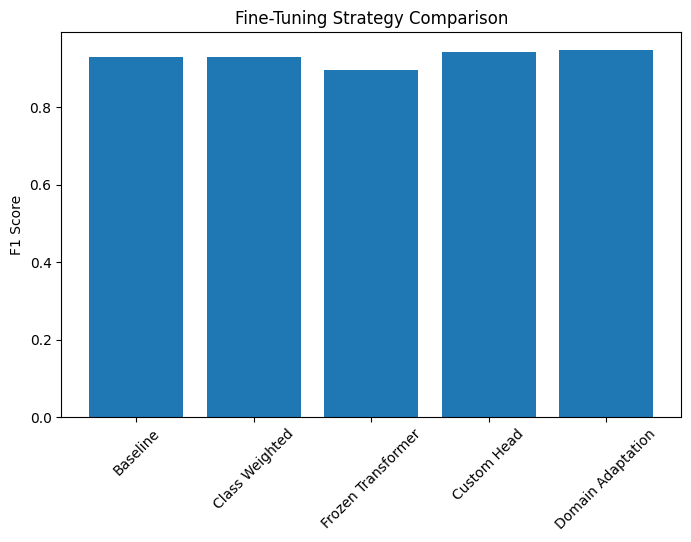

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Method"], results["F1"])

plt.xticks(rotation=45)

plt.ylabel("F1 Score")

plt.title("Fine-Tuning Strategy Comparison")

plt.show()

In [169]:
best_method = results.sort_values("F1", ascending=False).iloc[0]

print(best_method)

Method      Domain Adaptation
Accuracy             0.919512
F1                   0.946688
Name: 4, dtype: object


In [170]:
#save the best model
adapted_trainer.save_model("best_smiles_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Final Project pipeline

SMILES dataset

      ↓
Data preprocessing

      ↓
Tokenization

      ↓
ChemBERTa model

      ↓
Fine-tuning experiments
      ├ Baseline
      ├ Class weights
      ├ Frozen layers
      ├ Partial freezing
      ├ Custom classification head
      └ Domain adaptation
      ↓
Model comparison

      ↓
Best model selection

      ↓
Deployment / inference

# Deployment

In [176]:
!pip install -q gradio

In [177]:
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load the best model and tokenizer
model_path = "best_smiles_classifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

def predict_smiles(smiles: str) -> str:
    inputs = tokenizer(
        smiles,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    # Assuming 0 is non-permeable and 1 is permeable based on the dataset
    return "Permeable" if prediction == 1 else "Non-Permeable"

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
iface = gr.Interface(
    fn=predict_smiles,
    inputs=gr.Textbox(lines=2, placeholder="Enter SMILES string here..."),
    outputs="text",
    title="SMILES Permeability Predictor",
    description="Predicts whether a given SMILES molecule is Permeable (1) or Non-Permeable (0)."
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bb304d06d1bfff81ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
